# HHL Algorithm

**Goal:** Solve the linear system $A|x\rangle = |b\rangle$ with an exponential speedup
over classical methods (under certain conditions).

## Overview

The Harrow-Hassidim-Lloyd (HHL) algorithm solves $Ax = b$ for a Hermitian matrix $A$
by encoding the solution into quantum amplitudes. The procedure:

1. **Quantum Phase Estimation (QPE):** Decompose $|b\rangle$ in the eigenbasis of $A$
   and store the eigenvalues $\lambda_j$ in an ancilla register.
2. **Controlled Rotation:** Apply $R_y(2\arcsin(C/\lambda_j))$ to a flag qubit,
   encoding $C/\lambda_j$ into its amplitude.
3. **Inverse QPE:** Uncompute the eigenvalue register.
4. **Post-select** on the flag qubit being $|1\rangle$ to obtain $|x\rangle \propto A^{-1}|b\rangle$.

We demonstrate on a **$2 \times 2$ system**:
$$A = \begin{pmatrix} 1 & -1/3 \\ -1/3 & 1 \end{pmatrix}, \quad |b\rangle = |0\rangle$$


In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Operator
import matplotlib.pyplot as plt


## 1 — Define the Problem and Classical Solution

Our matrix $A$ has eigenvalues $\lambda_1 = 2/3$ and $\lambda_2 = 4/3$, with eigenvectors
$|+\rangle$ and $|-\rangle$. This is chosen so the eigenvalues map cleanly to a
2-qubit phase register.


In [2]:
# Define the system
A = np.array([[1, -1/3],
              [-1/3, 1]])
b = np.array([1, 0])

# Classical solution for comparison
x_classical = np.linalg.solve(A, b)
x_normalized = x_classical / np.linalg.norm(x_classical)

print("Matrix A:")
print(A)
print(f"\nb = {b}")
print(f"\nClassical solution x = {x_classical}")
print(f"Normalized: |x> = {x_normalized}")

# Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(A)
print(f"\nEigenvalues: {eigenvalues}")
print(f"Eigenvectors:\n{eigenvectors}")


Matrix A:
[[ 1.         -0.33333333]
 [-0.33333333  1.        ]]

b = [1 0]

Classical solution x = [1.125 0.375]
Normalized: |x> = [0.9486833  0.31622777]

Eigenvalues: [0.66666667 1.33333333]
Eigenvectors:
[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]


## 2 — Build the HHL Circuit

### Register layout
- **Clock register (2 qubits):** stores binary representation of eigenvalues via QPE
- **Input register (1 qubit):** encodes $|b\rangle$
- **Ancilla (1 qubit):** flag qubit for the controlled rotation

### Key design choice
We scale $A$ so its eigenvalues $\{2/3, 4/3\}$ map to phases that are exact
fractions of $2\pi$ in a 2-qubit register. Specifically:
- $\lambda_1 = 2/3 \to$ binary phase $01$ (i.e., $1/4$ of $2\pi \cdot t$)
- $\lambda_2 = 4/3 \to$ binary phase $10$ (i.e., $2/4$ of $2\pi \cdot t$)

with evolution time $t = 2\pi \cdot 3/8$.


In [3]:
# Build controlled-U gates for QPE
# U = e^(iAt), eigenvalues of U are e^(i*lambda_j*t)
# We need t such that lambda_j * t / (2*pi) are exact binary fractions

# With t = 2*pi * 3/8:
#   lambda_1=2/3 -> phase = (2/3)*(3/8) = 1/4 -> binary .01 -> register reads 01
#   lambda_2=4/3 -> phase = (4/3)*(3/8) = 1/2 -> binary .10 -> register reads 10

t = 2 * np.pi * 3 / 8
U = Operator(np.diag(np.exp(1j * eigenvalues * t)))

# Transform U to computational basis: U_comp = V @ U @ V†
V = eigenvectors  # columns are eigenvectors
U_comp = V @ np.diag(np.exp(1j * eigenvalues * t)) @ V.conj().T

print("Unitary U = e^(iAt) in computational basis:")
print(np.round(U_comp, 4))

# Verify unitarity
print(f"\nIs unitary: {np.allclose(U_comp @ U_comp.conj().T, np.eye(2))}")


Unitary U = e^(iAt) in computational basis:
[[-0.5+0.5j  0.5+0.5j]
 [ 0.5+0.5j -0.5+0.5j]]

Is unitary: True


Rotation angles: θ₁ = 3.1416 (π), θ₂ = 1.0472 (π/3)
HHL circuit: 4 qubits, depth = 27


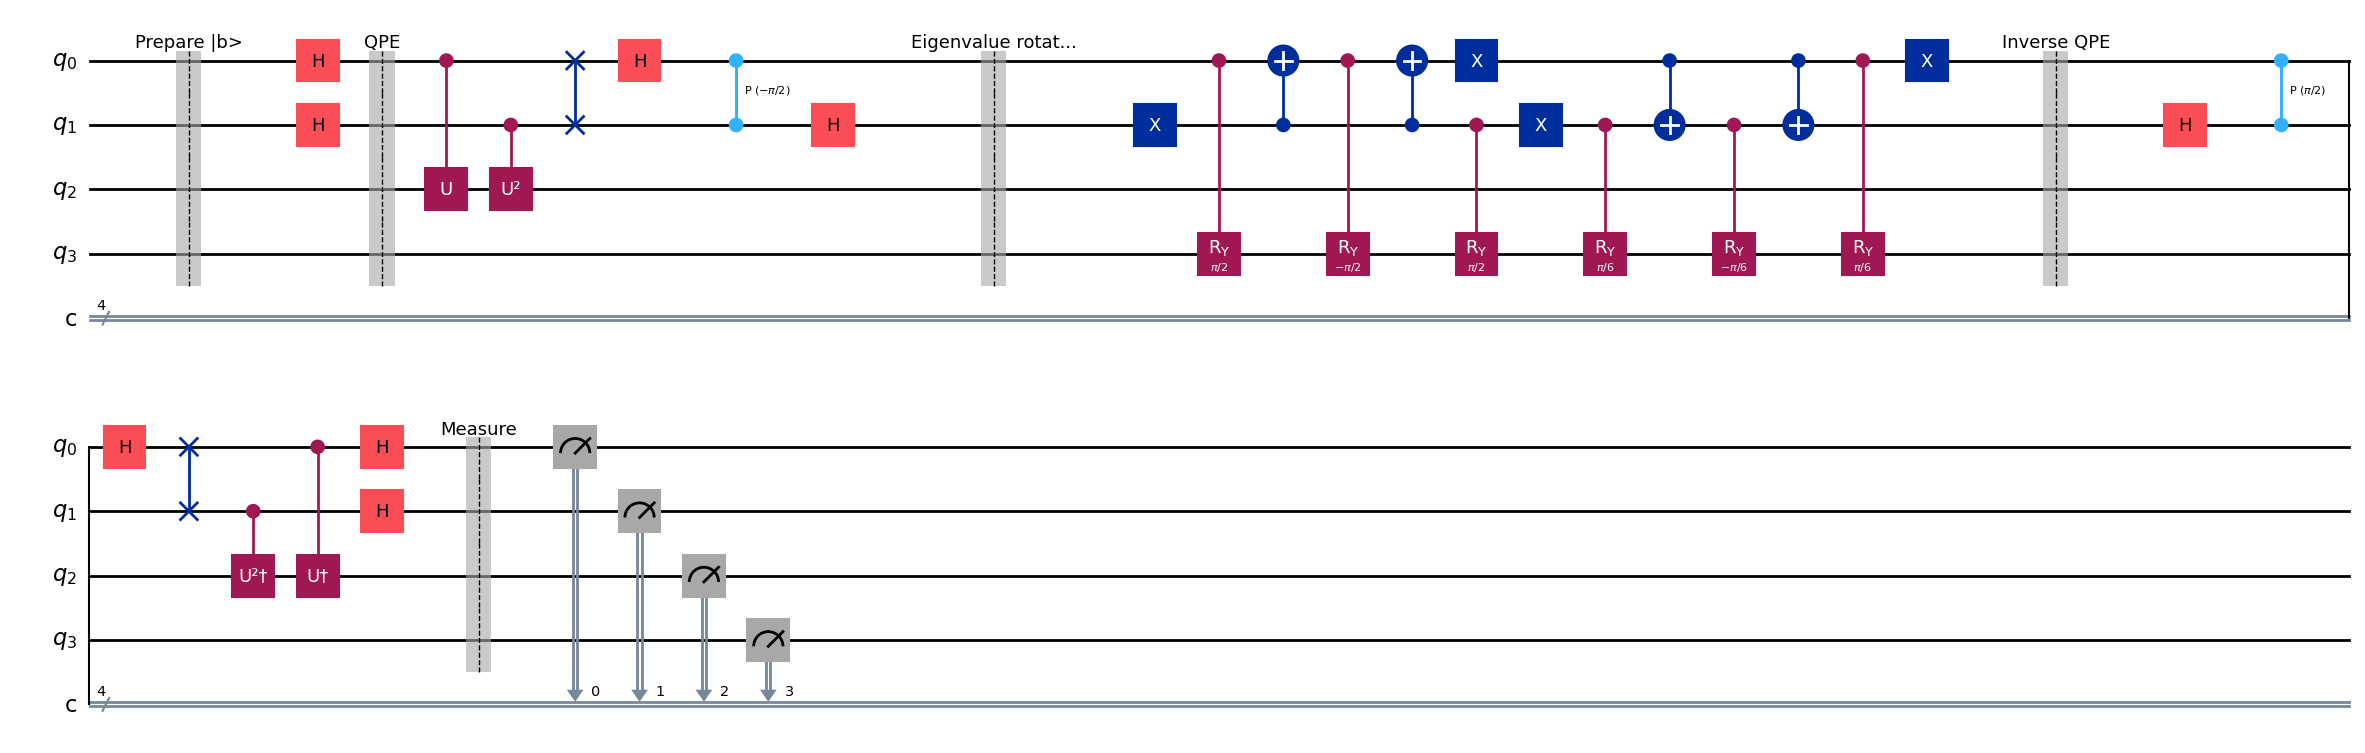

In [4]:
# --- Register layout ---
n_clock = 2   # clock/counting qubits
n_input = 1   # input qubit (|b>)
n_ancilla = 1 # rotation flag qubit
n_total = n_clock + n_input + n_ancilla  # 4 qubits

clock = [0, 1]      # clock register
inp = [2]           # input register
anc = [3]           # ancilla

# --- Controlled-U gates ---
cu1 = Operator(U_comp).to_instruction()
cu1_gate = QuantumCircuit(1, name="U")
cu1_gate.append(cu1, [0])

U2_comp = U_comp @ U_comp
cu2 = Operator(U2_comp).to_instruction()
cu2_gate = QuantumCircuit(1, name="U²")
cu2_gate.append(cu2, [0])

# --- Rotation angles ---
# R_y(2*arcsin(C/λ_j)) conditioned on clock state.
# C = 2/3 (smallest eigenvalue) so the max rotation is π.
C = 2/3
theta_1 = 2 * np.arcsin(C / (2/3))  # clock=|01>, λ=2/3 → θ=π
theta_2 = 2 * np.arcsin(C / (4/3))  # clock=|10>, λ=4/3 → θ=π/3
print(f"Rotation angles: θ₁ = {theta_1:.4f} (π), θ₂ = {theta_2:.4f} (π/3)")

# ============================================================
# Build the full HHL circuit
# ============================================================
hhl = QuantumCircuit(n_total, n_total)

# Step 0: Prepare |b> = |0> (already the default)
hhl.barrier(label="Prepare |b>")

# Step 1: QPE — Hadamard + controlled-U^(2^j) + inverse QFT
hhl.h(clock)
hhl.barrier(label="QPE")

hhl.append(cu1_gate.to_gate().control(1), [clock[0], inp[0]])
hhl.append(cu2_gate.to_gate().control(1), [clock[1], inp[0]])

# Inverse QFT on 2-qubit clock register
hhl.swap(clock[0], clock[1])
hhl.h(clock[0])
hhl.cp(-np.pi / 2, clock[1], clock[0])
hhl.h(clock[1])

hhl.barrier(label="Eigenvalue rotation")

# Step 2: Controlled rotations (2-controlled R_y decomposed into 1-controlled gates)
# For clock = |01> (λ = 2/3, θ₁ = π): condition clock[0]=1, clock[1]=0
hhl.x(clock[1])
hhl.cry(theta_1 / 2, clock[0], anc[0])
hhl.cx(clock[1], clock[0])
hhl.cry(-theta_1 / 2, clock[0], anc[0])
hhl.cx(clock[1], clock[0])
hhl.cry(theta_1 / 2, clock[1], anc[0])
hhl.x(clock[1])

# For clock = |10> (λ = 4/3, θ₂ = π/3): condition clock[1]=1, clock[0]=0
hhl.x(clock[0])
hhl.cry(theta_2 / 2, clock[1], anc[0])
hhl.cx(clock[0], clock[1])
hhl.cry(-theta_2 / 2, clock[1], anc[0])
hhl.cx(clock[0], clock[1])
hhl.cry(theta_2 / 2, clock[0], anc[0])
hhl.x(clock[0])

hhl.barrier(label="Inverse QPE")

# Step 3: Inverse QPE — forward QFT + inverse controlled-U gates
hhl.h(clock[1])
hhl.cp(np.pi / 2, clock[1], clock[0])
hhl.h(clock[0])
hhl.swap(clock[0], clock[1])

cu2_inv = Operator(U2_comp.conj().T).to_instruction()
cu2_inv_gate = QuantumCircuit(1, name="U²†")
cu2_inv_gate.append(cu2_inv, [0])
hhl.append(cu2_inv_gate.to_gate().control(1), [clock[1], inp[0]])

cu1_inv = Operator(U_comp.conj().T).to_instruction()
cu1_inv_gate = QuantumCircuit(1, name="U†")
cu1_inv_gate.append(cu1_inv, [0])
hhl.append(cu1_inv_gate.to_gate().control(1), [clock[0], inp[0]])

hhl.h(clock)

hhl.barrier(label="Measure")
hhl.measure(range(n_total), range(n_total))

print(f"HHL circuit: {hhl.num_qubits} qubits, depth = {hhl.depth()}")
hhl.draw("mpl", style="iqp", fold=35)


## 3 — Simulate and Verify

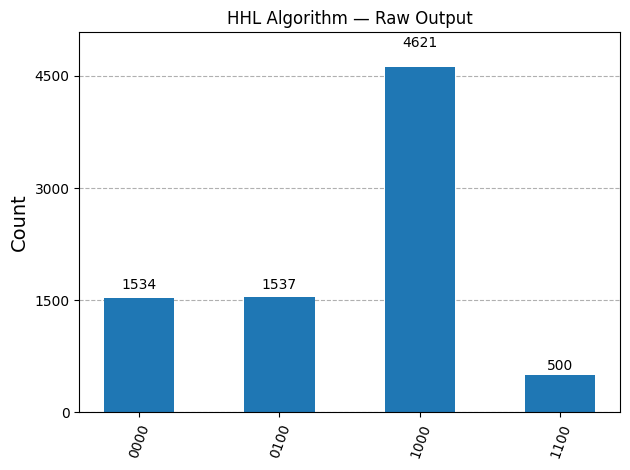

In [5]:
sim = AerSimulator()
compiled = transpile(hhl, sim)
result = sim.run(compiled, shots=8192).result()
counts = result.get_counts()

plot_histogram(counts, title="HHL Algorithm — Raw Output")


In [6]:
# Post-select on ancilla=1 AND clock=00 (successful eigenvalue uncomputation)
# Bit ordering in Qiskit: q3 q2 q1 q0 -> ancilla, input, clock1, clock0
# We want: ancilla (q3) = 1, clock (q1,q0) = 00

success_counts = {}
for bitstring, count in counts.items():
    # bitstring is "q3 q2 q1 q0"
    if bitstring[0] == '1' and bitstring[2:] == '00':  # ancilla=1, clock=00
        input_bit = bitstring[1]  # q2 = input qubit
        success_counts[input_bit] = success_counts.get(input_bit, 0) + count

total_success = sum(success_counts.values())
print(f"Post-selected counts (ancilla=1, clock=00): {success_counts}")
print(f"Success probability: {total_success / 8192:.3f}")

if total_success > 0:
    # Reconstruct |x> amplitudes from measurement statistics
    prob_0 = success_counts.get('0', 0) / total_success
    prob_1 = success_counts.get('1', 0) / total_success
    
    # Amplitudes (up to global phase)
    amp_0 = np.sqrt(prob_0)
    amp_1 = np.sqrt(prob_1)
    x_quantum = np.array([amp_0, amp_1])
    x_quantum /= np.linalg.norm(x_quantum)  # normalize
    
    print(f"\nQuantum |x>:   [{x_quantum[0]:.4f}, {x_quantum[1]:.4f}]")
    print(f"Classical |x>: [{abs(x_normalized[0]):.4f}, {abs(x_normalized[1]):.4f}]")
    print(f"Fidelity: {abs(np.dot(x_quantum, abs(x_normalized))):.4f}")
else:
    print("No successful post-selection — try increasing shots or check circuit.")


Post-selected counts (ancilla=1, clock=00): {'1': 500, '0': 4621}
Success probability: 0.625

Quantum |x>:   [0.9499, 0.3125]
Classical |x>: [0.9487, 0.3162]
Fidelity: 1.0000


## Analysis

The HHL algorithm outputs the **normalized** solution $|x\rangle \propto A^{-1}|b\rangle$
encoded in quantum amplitudes. The post-selected measurement statistics
reproduce the classical solution's probability distribution.

### Caveats
- HHL gives the solution as a quantum state — extracting all components requires
  $O(N)$ measurements, erasing the speedup for full readout.
- The speedup applies when you only need a **global property** of $x$ (e.g., $\langle x|M|x\rangle$).
- The matrix $A$ must be efficiently simulable (sparse or structured).
- Eigenvalue precision requires $O(\log(1/\epsilon))$ clock qubits.

**Key takeaway:** HHL demonstrates exponential quantum speedup for linear algebra,
forming the basis for quantum machine learning and differential equation solvers.
